## Analysis Sensitivity Section

In [5]:
import numpy as np
import pandas as pd
from pathlib import Path
import healpy as hp 

import matplotlib.pyplot as plt

In [6]:
%load_ext autoreload
%autoreload 2

from CHORD_Sensitivity import Telescope
from CHORD_Sensitivity.constants import K_B, OMEGA

chord = Telescope('CHORD')
pathfinder = Telescope('PATHFINDER')

output_dir = Path("../../thesis/plots/sensitivity/")
output_dir.mkdir(parents=True, exist_ok=True)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
freq_range = np.linspace(300, 1500, 13) # MHz
bandwidth_range = np.array([5, 20, 200]) # kHz

chord_rms = [chord.sigma_rms(freq=freq_range, delta_nu=bandwidth * 1e3) for bandwidth in bandwidth_range]
pathfinder_rms = [pathfinder.sigma_rms(freq=freq_range, delta_nu=bandwidth * 1e3) for bandwidth in bandwidth_range]

chord_df = pd.DataFrame(
    np.array(chord_rms).T * 1e3,  # Convert to mJy/beam
    index=freq_range,
    columns=bandwidth_range.astype(str) + ' kHz'
).rename_axis(index="Frequency", columns="Bandwidth")

pathfinder_df = pd.DataFrame(
    np.array(pathfinder_rms).T * 1e3,  # Convert to mJy/beam
    index=freq_range,
    columns=bandwidth_range.astype(str) + ' kHz'
).rename_axis(index="Frequency", columns="Bandwidth")

sigma_rms_df = pd.concat(
    {"CHORD": chord_df, "PATHFINDER": pathfinder_df},
    axis=1
)
sigma_rms_df.index.name = "Frequency (MHz)"
sigma_rms_df.columns.names = ["Telescope", "Bandwidth"]
sigma_rms_df

Telescope           CHORD                     PATHFINDER                     
Bandwidth           5 kHz    20 kHz   200 kHz      5 kHz     20 kHz   200 kHz
Frequency (MHz)                                                              
300.0            2.130266  1.065133  0.336825  17.156453   8.578227  2.712673
400.0            2.459820  1.229910  0.388932  19.810566   9.905283  3.132325
500.0            2.750162  1.375081  0.434839  22.148886  11.074443  3.502046
600.0            3.012651  1.506326  0.476342  24.262889  12.131444  3.836300
700.0            3.254035  1.627018  0.514508  26.206915  13.103457  4.143677
800.0            3.478710  1.739355  0.550032  28.016371  14.008185  4.429777
900.0            3.689729  1.844865  0.583397  29.715848  14.857924  4.698488
1000.0           3.889316  1.944658  0.614955  31.323254  15.661627  4.952641
1100.0           4.079149  2.039575  0.644970  32.852106  16.426053  5.194374
1200.0           4.260532  2.130266  0.673649  34.312906  17.156453  5.425347
1300.0           4.434503  2.217251  0.701156  35.714005  17.857003  5.646880
1400.0           4.601901  2.300951  0.727624  37.062175  18.531087  5.860044
1500.0           4.763420  2.381710  0.753163  38.362995  19.181498  6.065722

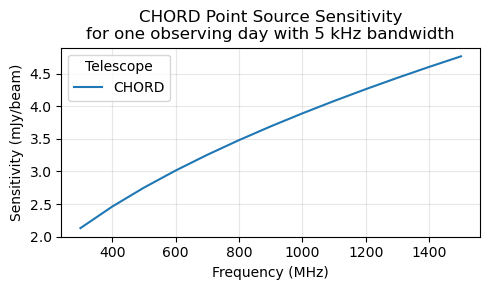

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))

bandwidth = 5e3 # kHz
freq_range = np.linspace(300, 1500, 13) # MHz

ax.plot(
    freq_range,
    chord.sigma_rms(freq=freq_range, delta_nu=bandwidth)*1e3,  # Convert to mJy/beam
    linestyle="-",
    label=f"CHORD",
)
# ax.plot(
#     freq_range,
#     pathfinder.sigma_rms(freq=freq_range, delta_nu=bandwidth),
#     linestyle="--",
#     label=f"PATHFINDER",
# )

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Sensitivity (mJy/beam)")
ax.set_title("CHORD Point Source Sensitivity\nfor one observing day with 5 kHz bandwidth")
ax.grid(True, alpha=0.3)
ax.legend(title="Telescope")
plt.tight_layout()

fig.savefig(output_dir / "chord_point_source_sensitivity.png", dpi=300, bbox_inches="tight")

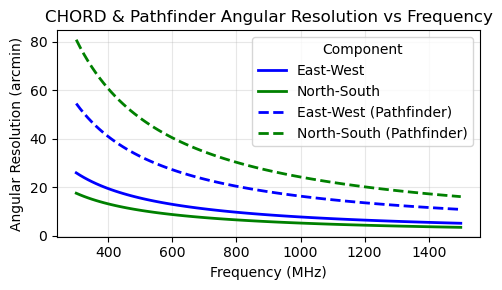

In [9]:
freq = np.linspace(300, 1500, 100)  # MHz
rad_to_arcmin = (180 / np.pi) * 60

# S_FWHM returns a list of (EW, NS) pairs -> (2, N) arrays in arcmin
c_ew, c_ns = np.array(chord.S_FWHM(freq)).T * rad_to_arcmin
p_ew, p_ns = np.array(pathfinder.S_FWHM(freq)).T * rad_to_arcmin

fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(freq, c_ew, c='blue',  label="East-West", linewidth=2)
ax.plot(freq, c_ns, c='green', label="North-South", linewidth=2)
ax.plot(freq, p_ew, c='blue',  label="East-West (Pathfinder)",   linestyle="--", linewidth=2)
ax.plot(freq, p_ns, c='green', label="North-South (Pathfinder)", linestyle="--", linewidth=2)

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Angular Resolution (arcmin)")
ax.set_title("CHORD & Pathfinder Angular Resolution vs Frequency")
ax.grid(True, alpha=0.3)
ax.legend(title="Component")

plt.tight_layout()
plt.savefig(output_dir / "chord_pathfinder_angular_resolution.png", dpi=300, bbox_inches="tight")


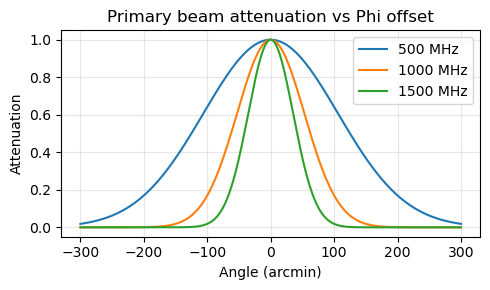

In [10]:
arcmins = np.linspace(-300, 300, 500)
arcmins_rad = np.deg2rad(arcmins / 60)

fig, ax = plt.subplots(figsize=(5, 3))
for freq in [500, 1000, 1500]:  # MHz
    freq_range = [freq] * len(arcmins_rad)
    phi_offset = chord.D_phi(phi_offset=arcmins_rad, freq=freq_range)
    ax.plot(arcmins, phi_offset, label=f"{freq} MHz")
ax.set_xlabel("Angle (arcmin)")
ax.set_ylabel("Attenuation")
ax.set_title("Primary beam attenuation vs Phi offset")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(output_dir / "chord_primary_beam_attenuation.png", dpi=300, bbox_inches="tight")

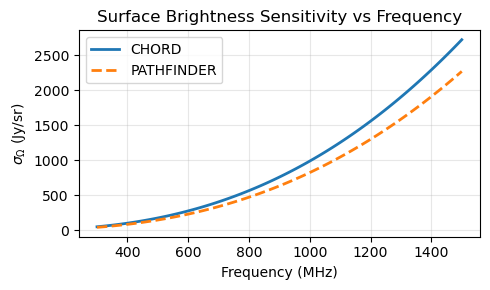

In [11]:
freq_range = np.linspace(300, 1500, 100).tolist()  # list to satisfy type checker
bandwidth = 5 * 1e3  # Hz (5 kHz)

chord_sigma = np.array(chord.sigma_rms(freq=freq_range, delta_nu=bandwidth))
pathfinder_sigma = np.array(pathfinder.sigma_rms(freq=freq_range, delta_nu=bandwidth))

chord_solid_angle = np.array(chord.S_solid_angle(freq=freq_range))
pathfinder_solid_angle = np.array(pathfinder.S_solid_angle(freq=freq_range))

surface_brightness_chord = chord_sigma / chord_solid_angle
surface_brightness_pathfinder = pathfinder_sigma / pathfinder_solid_angle

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(freq_range, surface_brightness_chord, label="CHORD", linewidth=2)
ax.plot(freq_range, surface_brightness_pathfinder, label="PATHFINDER", linestyle="--", linewidth=2)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel(r"$\sigma_\Omega$ (Jy/sr)")
ax.set_title("Surface Brightness Sensitivity vs Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "chord_pathfinder_surface_brightness_sensitivity.png", dpi=300, bbox_inches="tight")

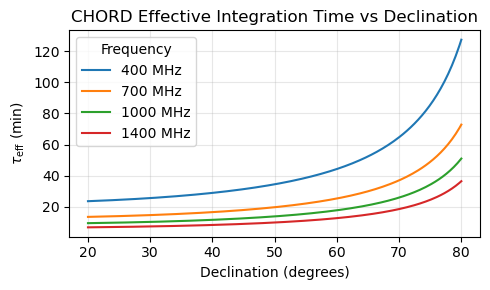

In [15]:
fig, ax = plt.subplots(figsize=(5, 3))

# Declination sweep across the CHORD observable range.
dec_range = np.linspace(chord.params['min_dec'], chord.params['max_dec'], 200)  # degrees

for freq in [400, 700, 1000, 1400]:  # MHz
    tau_eff = chord.tau_eff(phi_offset=0.0, freq=freq, dec_deg=dec_range) / 60  # minutes
    ax.plot(dec_range, tau_eff, label=f"{freq} MHz")

ax.set_xlabel("Declination (degrees)")
ax.set_ylabel(r"$\tau_{\mathrm{eff}}$ (min)")
ax.set_title("CHORD Effective Integration Time vs Declination")
ax.grid(True, alpha=0.3)
ax.legend(title="Frequency")
plt.tight_layout()

fig.savefig(output_dir / "chord_tau_eff_vs_declination.png", dpi=300, bbox_inches="tight")


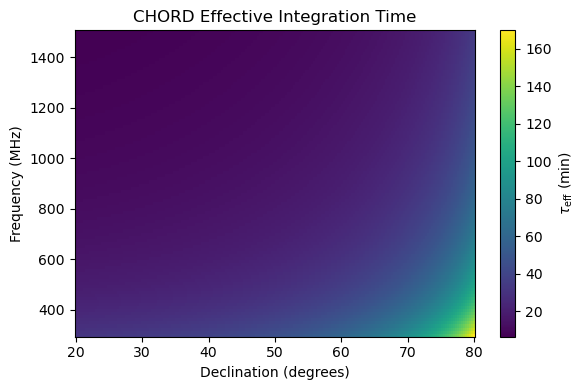

In [16]:
freqs = np.linspace(300, 1500, 100)  # MHz, y-axis
decs = np.linspace(chord.params['min_dec'], chord.params['max_dec'], 200)  # degrees, x-axis

# convert_freq_to_Hz only handles 1-D freq, so build the grid one frequency
# row at a time (dec sweeps along each row).
tau_grid = np.array([
    chord.tau_eff(phi_offset=0.0, freq=f, dec_deg=decs) / 60  # minutes
    for f in freqs
])  # shape (n_freq, n_dec)

fig, ax = plt.subplots(figsize=(6, 4))
mesh = ax.pcolormesh(decs, freqs, tau_grid, shading="auto", cmap="viridis")

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label(r"$\tau_{\mathrm{eff}}$ (min)")

ax.set_xlabel("Declination (degrees)")
ax.set_ylabel("Frequency (MHz)")
ax.set_title("CHORD Effective Integration Time")
plt.tight_layout()

fig.savefig(output_dir / "chord_tau_eff_heatmap.png", dpi=300, bbox_inches="tight")


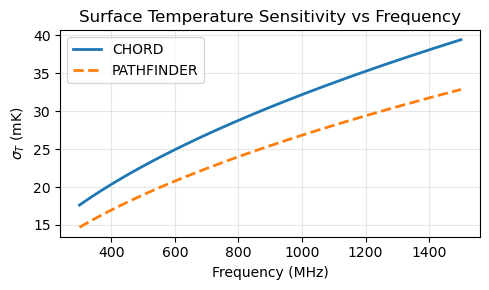

In [12]:
freq_range = np.linspace(300, 1500, 100).tolist()  # list to satisfy type checker
bandwidth = 5 * 1e3  # Hz (5 kHz)

chord_sigma = chord.sigma_rms(freq=freq_range, delta_nu=bandwidth)
pathfinder_sigma = pathfinder.sigma_rms(freq=freq_range, delta_nu=bandwidth)

chord_sens = np.array(
    chord.surface_temperature(freq=freq_range, sigma_rms=chord_sigma, delta_nu=bandwidth)
) * 1e3  # mK/beam
pathfinder_sens = np.array(
    pathfinder.surface_temperature(freq=freq_range, sigma_rms=pathfinder_sigma, delta_nu=bandwidth)
) * 1e3  # mK/beam

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(freq_range, chord_sens, label="CHORD", linewidth=2)
ax.plot(freq_range, pathfinder_sens, label="PATHFINDER", linewidth=2, linestyle="--")

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel(r"$\sigma_T$ (mK)")
ax.set_title("Surface Temperature Sensitivity vs Frequency")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
fig.savefig(output_dir / "chord_pathfinder_surface_temperature_5kHz.png", dpi=300, bbox_inches="tight")


/var/folders/1v/pf54418j6fj5541rk7ynqhgw0000gn/T/ipykernel_49657/2680363510.py:34: RuntimeWarning: All-NaN axis encountered
  hp_map = np.nanmin(maps, axis=0)


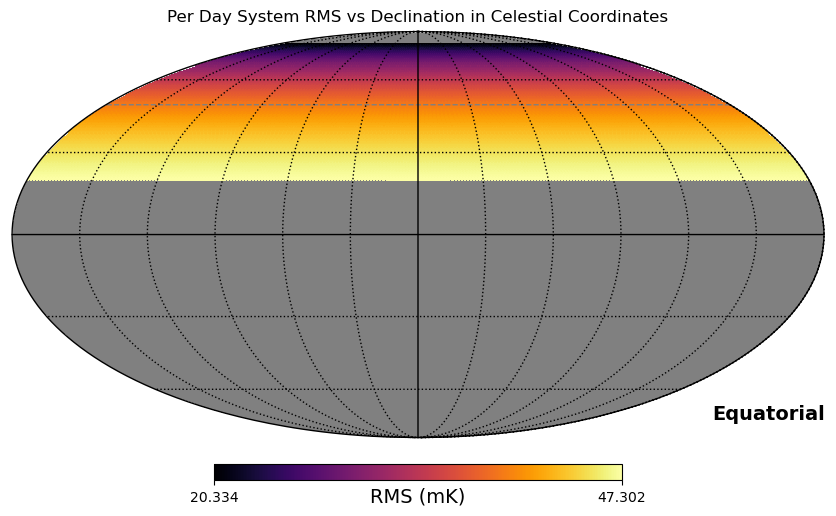

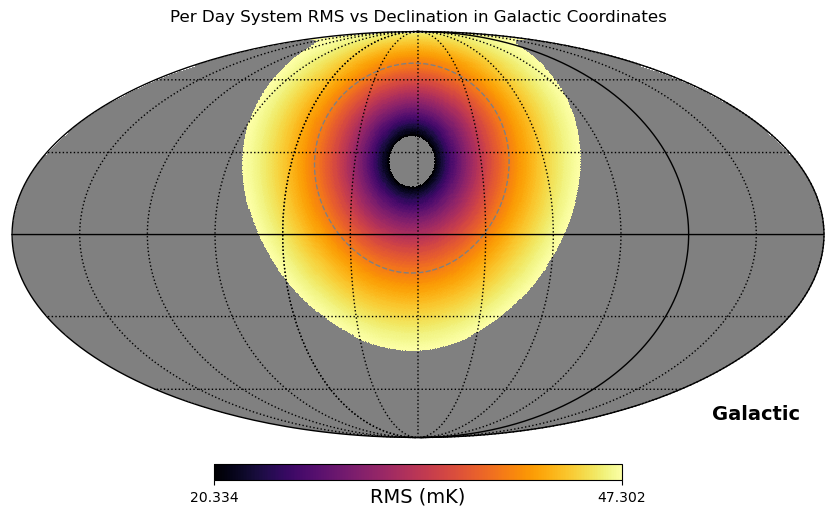

In [13]:
# Define the latitude (declination for zenith pointing)
CHORD_angles = np.linspace(20, 80, 100)  # degrees North
dec = 49
bandwidth = 5*1e3  # kHz

# Calculate the colatitude theta in radians (theta = 90° - declination)
theta_target = np.deg2rad(90 - CHORD_angles)
dec_center = np.deg2rad(90 - dec)

# Generate azimuthal angles phi from 0 to 2π for dense sampling to cover pixels
phi = np.linspace(0, 2 * np.pi, 10000)  # High density for better pixel coverage

# Choose a higher NSIDE for better resolution of the thin arc
nside = 128  # Increased from 16 for finer detail; adjust as needed

# Convert theta and phi to pixel indices and set those pixels to 0.5
# Use unique pixels to avoid overwriting
maps = []
ref_freq = 1.5e9  # Reference frequency for surface temperature calculation
for n in range(len(theta_target)):
    pointing_angle_deg = CHORD_angles[n]
    theta = theta_target[n]
    hp_map = np.full(hp.nside2npix(nside), np.nan)
    pixels = hp.ang2pix(nside, theta * np.ones_like(phi), phi)
    unique_pixels = np.unique(pixels)
    hp_map[unique_pixels] = chord.surface_temperature(
        freq=ref_freq,
        sigma_rms=chord.sigma_rms(freq=ref_freq, delta_nu=bandwidth, dec_deg=pointing_angle_deg),
        delta_nu=bandwidth
    )*1e3
    maps.append(hp_map)

# Combine all maps into a single HEALPix map
hp_map = np.nanmin(maps, axis=0)

hp_map[hp_map == 0] = np.nan  # Set non-arc pixels to NaN for better visualization

# First plot: Celestial coordinates
hp.mollview(hp_map, title='Per Day System RMS vs Declination in Celestial Coordinates',
            cmap='inferno', unit='RMS (mK)', coord='C', min=np.nanmin(hp_map), max=np.nanmax(hp_map))
hp.projplot(dec_center * np.ones_like(phi), phi, lw=1, color='grey', linestyle='dashed', coord='C')
hp.graticule()
plt.savefig(output_dir / "RMS_declination_map_celestial.png", dpi=300, bbox_inches="tight")
plt.show()

# Second plot: Galactic coordinates
hp.mollview(hp_map, title='Per Day System RMS vs Declination in Galactic Coordinates',
            cmap='inferno', unit='RMS (mK)', coord=['C', 'G'], rot=(120, 0))
hp.projplot(dec_center * np.ones_like(phi), phi, lw=1, color='grey', linestyle='dashed', coord='C')
hp.graticule()
plt.savefig(output_dir / "RMS_declination_map_galactic.png", dpi=300, bbox_inches="tight")
plt.show()